In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# @title Texto de título predeterminado
data = pd.read_csv('https://raw.githubusercontent.com/Adrian-Cancino/Machine-Learning-ScikitLearn/refs/heads/main/Conjuntos%20de%20datos/Advertising.csv')
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
data = data.iloc[:, 1:]
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

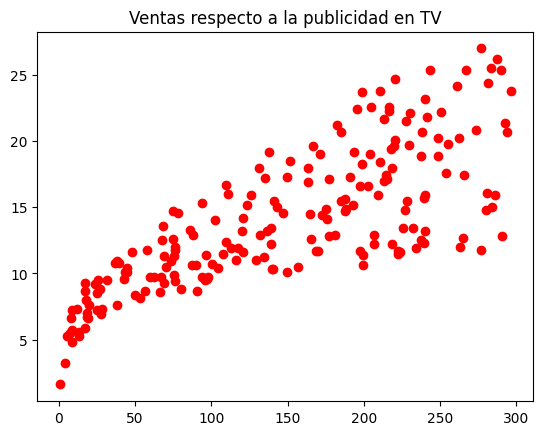

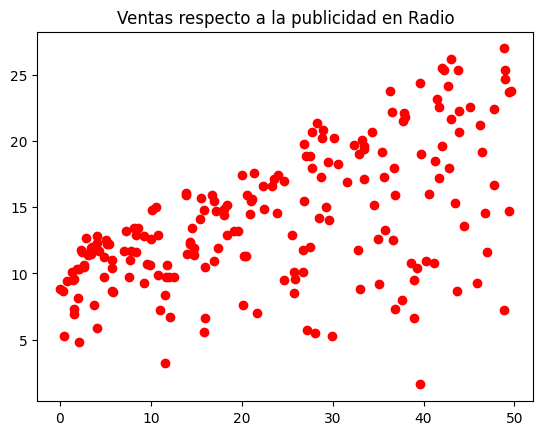

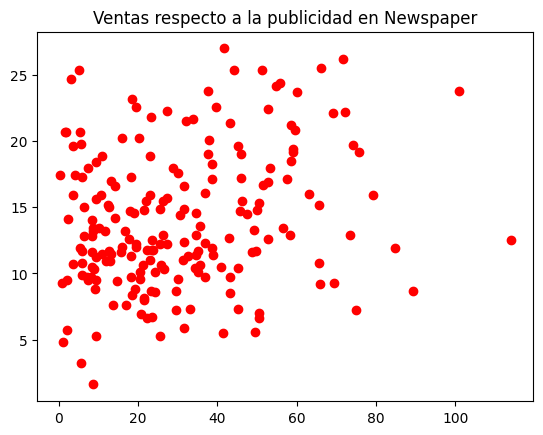

In [ ]:
columnas = ['TV', 'Radio', 'Newspaper'] # Exclude 'Sales' as it's the target variable
for columna in columnas:
  plt.plot(data[columna], data['Sales'], 'ro') # Pass x and y data as separate arguments
  plt.title('Ventas respecto a la publicidad en %s' %columna)
  plt.show() # Correctly call the show method

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
x = data['TV'].values.reshape(-1,1)
y = data['Sales'].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

(160, 1)
(40, 1)


LinearRegression()

In [ ]:
predict = lin_reg.predict(x_test)
print(f"Predicciones:\n{predict}\n Reales:\n{y_test}")

Predicciones:
[14.71794394 16.2115484  20.74819743  7.66403631 17.37013877 10.61402143
 17.2072847   9.44612512 17.46785121 15.2669948   8.58532504  9.73460946
 18.03086098  7.37089899 13.61053628 15.03899911  7.45930549 16.31391381
 10.62332738 18.16579721 17.79821232 10.27435438  8.88776831 18.79394862
 10.33019006  9.60897918 17.05373658 13.60123034 11.17703121  7.51048819
 16.41627922 10.339496   16.37440246  7.90599093 20.18053468 18.203021
  9.36702457 19.85482655 12.57292322  8.39920611]
 Reales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9]


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, predict)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

#R2
print('R2:' ,r2_score(y_test, predict))




RMSE: 3.194472431998898
R2: 0.6766954295627076


<function matplotlib.pyplot.show(close=None, block=None)>

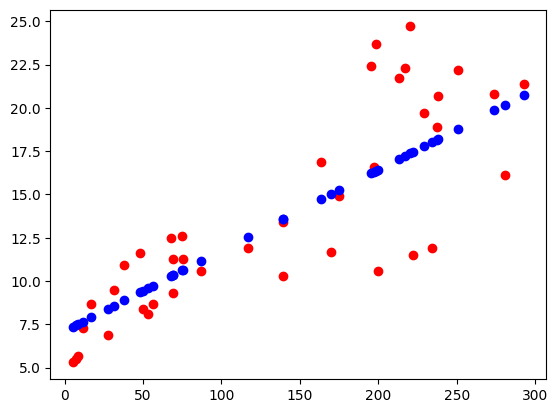

In [ ]:
plt.plot(x_test, y_test, 'ro')
plt.plot(x_test, predict, 'bo')
plt.show

In [ ]:
def modelo_regresion_lineal(independiente):
  x = data[independiente].values.reshape(-1,1)
  y = data['Sales'].values
  x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
  lin_reg = LinearRegression()
  lin_reg.fit(x_train, y_train)
  predict = lin_reg.predict(x_test)
  print(f"Predicciones:\n{predict}\n Reales:\n{y_test}")
  from sklearn.metrics import mean_squared_error
  import numpy as np
  mse = mean_squared_error(y_test, predict)
  rmse = np.sqrt(mse)
  print(f"RMSE: {rmse}")
  print('R2:' ,r2_score(y_test, predict))
  plt.plot(x_test, y_test, 'ro')
  plt.plot(x_test, predict, 'bo')
  plt.show()


Predicciones:
[15.88332197 19.17427219 15.20877938 16.96667826 19.44000109 16.57830525
 18.39752618 11.79518506 10.11904893 14.02321968 14.45247405 10.58918467
 10.11904893 15.53583034  9.85332003 11.01843905 15.16789801 14.18674516
 13.57352462 15.04525391 16.02640677 16.9053562  17.66166153 16.88491552
 11.32504931  9.83287934 18.21356002 12.38796491 11.83606643 14.98393185
  9.95552345 13.61440599 19.52176383 18.35664481 12.26532081 16.43522046
 19.0311874  15.33142349 12.42884628  9.7511166 ]
 Reales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9]
RMSE: 4.8216974799471926
R2: 0.2634309396999791


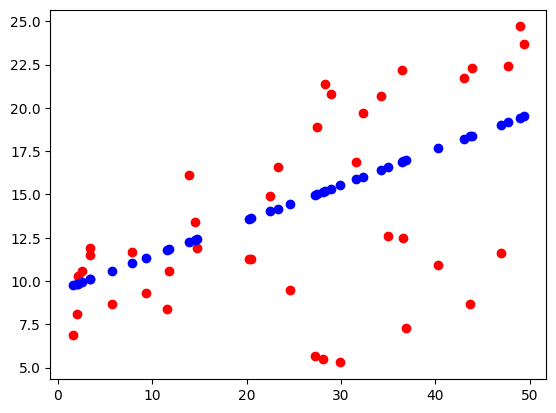

In [ ]:
modelo_regresion_lineal('Radio')

Predicciones:
[15.47167765 15.47167765 14.89203768 15.01155108 12.50176977 15.45972631
 13.93593052 13.41007158 13.09336108 14.19288432 12.44201307 14.08532226
 17.37791631 12.87226129 13.9000765  14.4139841  14.78447563 13.15909344
 14.25264102 12.96787201 16.74449532 19.12281189 13.02165304 16.63095759
 12.36432936 13.58934167 14.33032472 12.92006665 13.85824681 12.4360374
 13.57739033 13.40409591 15.89595021 17.65279712 14.52154616 12.62725883
 12.81848027 15.8780232  12.6332345  13.54751198]
 Reales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9]
RMSE: 5.533600454969853
R2: 0.029871749149522397


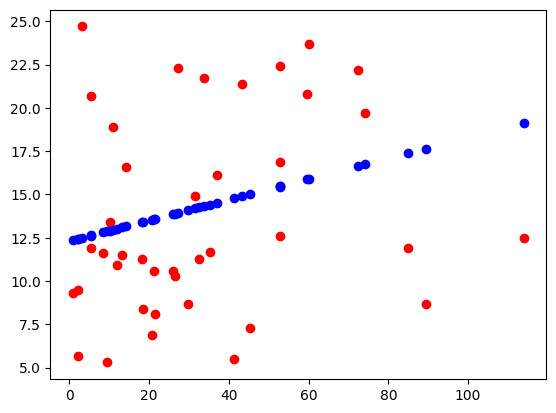

In [ ]:
modelo_regresion_lineal('Newspaper')

In [ ]:
import seaborn as sns

Predicciones:
[16.00205249 17.4873792  21.45480309  8.555338   15.85182707 11.90965624
 17.03605895  8.82431212 16.50429862 15.34771358  7.05960892  9.74502567
 21.08591102  6.25576839 13.42558958 15.32851807  8.13859612 15.41845657
 10.78587292 17.08058547 20.25998739 15.01024842  7.90445846 21.14363234
  8.7218854   9.15453655 17.25356225 12.49644323 10.96630762  5.98511985
 15.91289148  9.70712273 18.04757663 11.27517276 20.54252236 16.79788441
  8.19034931 21.49188447 11.20459844  7.91220451]
 Reales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9]
RMSE: 3.3260422878644853
R2: 0.649515280538585


<Axes: >

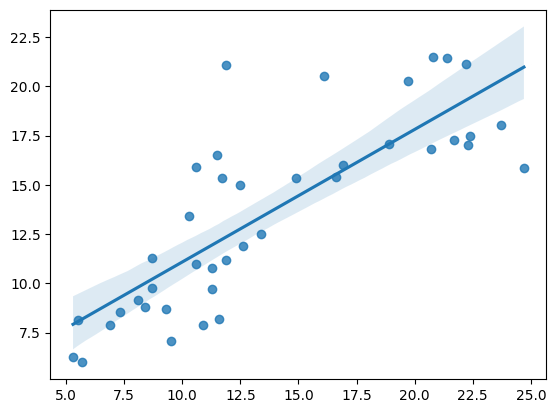

In [ ]:
  x = data.drop(['Radio', 'Sales'], axis=1).values
  y = data['Sales'].values
  x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
  lin_reg = LinearRegression()
  lin_reg.fit(x_train, y_train)
  predict = lin_reg.predict(x_test)
  print(f"Predicciones:\n{predict}\n Reales:\n{y_test}")
  from sklearn.metrics import mean_squared_error
  import numpy as np
  mse = mean_squared_error(y_test, predict)
  rmse = np.sqrt(mse)
  print(f"RMSE: {rmse}")
  print('R2:' ,r2_score(y_test, predict))
  sns.regplot(x=y_test, y=predict)

Predicciones:
[16.35747252 20.86299397 21.52505848 10.58719845 22.22459614 13.06070499
 21.09564403  7.47641062 13.62409831 15.15019438  9.12761147  6.62878923
 14.16531076  8.97073929  9.66825463 12.12821691  8.71252199 16.30911498
 10.26684186 18.89010391 19.4519532  13.03925601 12.41182149 21.20994137
  7.88771365  5.80255394 20.7764401  12.02358305  9.1784369   8.59012258
 12.46070487 10.03213267 21.34367738 12.11632301 18.23376459 20.22242395
 14.14999367 20.78067544 11.07322103  4.56335118]
 Reales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9]
RMSE: 1.7714254173033515
R2: 0.9005833101920356


<Axes: >

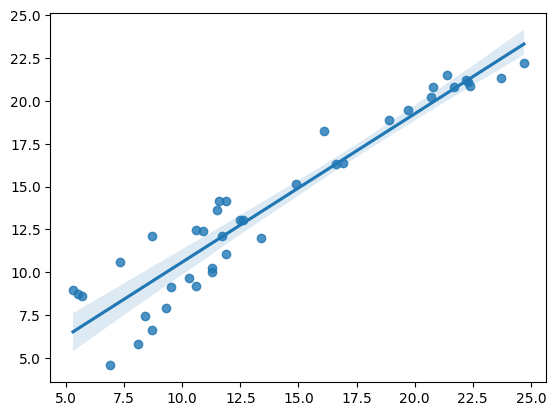

In [ ]:
  x = data.drop(['Newspaper', 'Sales'], axis=1).values
  y = data['Sales'].values
  x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
  lin_reg = LinearRegression()
  lin_reg.fit(x_train, y_train)
  predict = lin_reg.predict(x_test)
  print(f"Predicciones:\n{predict}\n Reales:\n{y_test}")
  from sklearn.metrics import mean_squared_error
  import numpy as np
  mse = mean_squared_error(y_test, predict)
  rmse = np.sqrt(mse)
  print(f"RMSE: {rmse}")
  print('R2:' ,r2_score(y_test, predict))
  sns.regplot(x=y_test, y=predict)

In [ ]:
#regresion polinomica
import pandas as pd
import numpy as np
years = [x for x in range(1,11)]
position = ["Puesto 1", "Puesto 2", "Puesto 3", "Puesto 4", "Puesto 5","Puesto 6", "Puesto 7", "Puesto 8", "Puesto 9", "Puesto 10"]
salary = [1000.0, 1150.0, 1260.0, 1600.0, 1900.0,2400.0, 3000.0, 4000.0, 5200.0, 6000.0]
data = {
    "posición": position,
    "años": years,
    "salario": salary
}

data = pd.DataFrame(data)
data.head()

,posición,años,salario
0,Puesto 1,1,1000.0
1,Puesto 2,2,1150.0
2,Puesto 3,3,1260.0
3,Puesto 4,4,1600.0
4,Puesto 5,5,1900.0


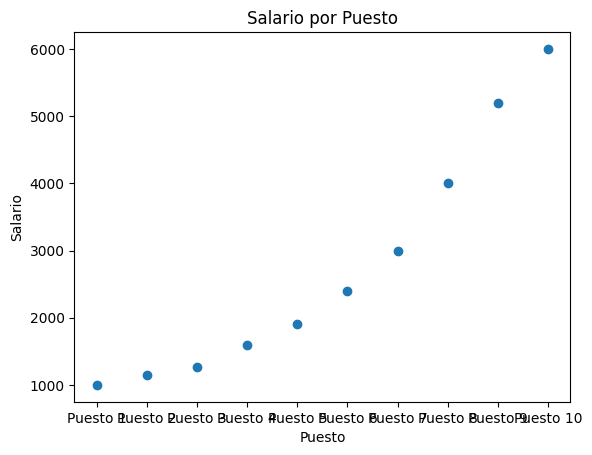

In [ ]:
    plt.scatter(data["posición"], data["salario"])
    plt.title("Salario por Puesto")
    plt.xlabel("Puesto")
    plt.ylabel("Salario")
    plt.show()

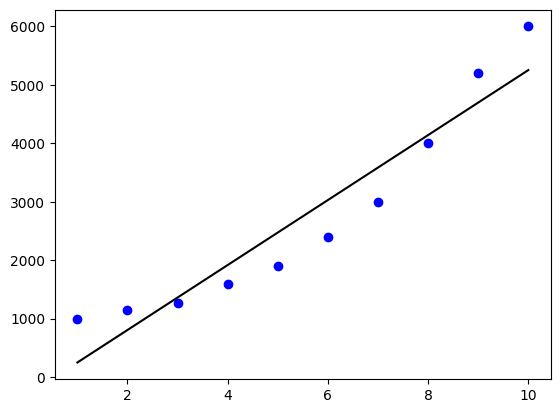

In [ ]:
x = data.iloc[:,1].values.reshape(-1, 1)
y = data.iloc[:,-1].values
regresion_multiple = LinearRegression()
regresion_multiple.fit(x, y)
plt.scatter(data['años'], data['salario'], color='blue')
plt.plot(x, regresion_multiple.predict(x), color='black')
plt.show()

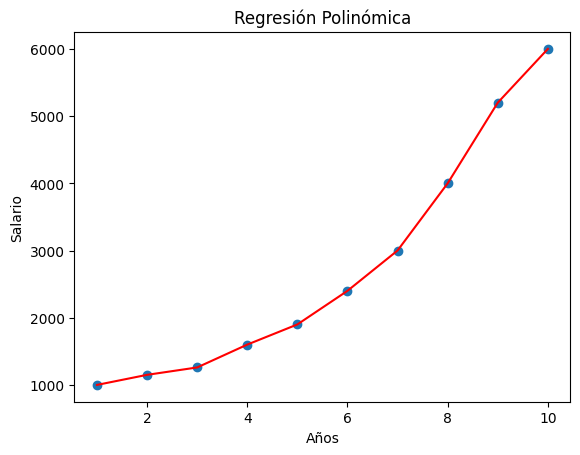

In [ ]:
import sklearn.preprocessing as pre
import sklearn.linear_model as lm
poly = pre.PolynomialFeatures(degree=9)
x_poly = poly.fit_transform(x)
regresion_2 = lm.LinearRegression()
regresion_2.fit(x_poly, y)
plt.scatter(data['años'], data['salario'])
plt.plot(data['años'], regresion_2.predict(poly.fit_transform(x)), color='red')
plt.title("Regresión Polinómica")
plt.xlabel("Años")
plt.ylabel("Salario")
plt.show()